# Experiment 03 — Encoding Strategies

**Research question:** Which quantum data encoding strategy performs best for particle physics classification?

We compare three strategies using 2 features / 2 layers / 5000 samples:

| Strategy | Description |
|----------|-------------|
| **Angle encoding** | Ry(xᵢ) — each feature maps to a rotation angle (paper default) |
| **Amplitude encoding** | Features encoded in the amplitudes of the quantum state |
| **Data reuploading** | Features are re-injected at each circuit layer |

Features: col 26 (m_bb) and col 4 (missing energy magnitude).

In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.metrics import roc_auc_score

from utils.data_utils import load_higgs, binary_accuracy

np.random.seed(42)

# Shared hyperparameters
N_FEATURES = 2
N_LAYERS   = 2
N_EPOCHS   = 30
BATCH_SIZE = 32
LR         = 0.01

X_train, X_val, X_test, y_train, y_val, y_test = load_higgs(
    '../data/HIGGS.csv.gz',
    n_features=N_FEATURES,
    feature_indices=[26, 4],
    scale_range=(0, np.pi),
)

Selected features (cols [26, 4]): ['m_bb', 'missing energy mag.']
Dataset: 5000 samples | 2 features | train=3000, val=1000, test=1000


## Strategy A — Angle Encoding (paper baseline)

In [2]:
dev = qml.device('default.qubit', wires=N_FEATURES)

@qml.qnode(dev, interface='autograd')
def circuit_angle(weights, x):
    # Angle encoding
    for i in range(N_FEATURES):
        qml.RY(x[i], wires=i)
    # Model circuit
    for l in range(N_LAYERS):
        for q in range(N_FEATURES):
            qml.Rot(weights[l,q,0], weights[l,q,1], weights[l,q,2], wires=q)
        for q in range(N_FEATURES - 1):
            qml.CNOT(wires=[q, q+1])
        if N_FEATURES > 1:
            qml.CNOT(wires=[N_FEATURES-1, 0])
    return qml.expval(qml.PauliZ(0))

## Strategy B — Data Reuploading

Re-inject the input features at each layer (Pérez-Salinas et al., 2020). This increases expressibility without adding qubits.

In [3]:
@qml.qnode(dev, interface='autograd')
def circuit_reupload(weights, x):
    for l in range(N_LAYERS):
        # Re-encode data at each layer
        for i in range(N_FEATURES):
            qml.RY(x[i], wires=i)
        # Trainable rotation + entanglement
        for q in range(N_FEATURES):
            qml.Rot(weights[l,q,0], weights[l,q,1], weights[l,q,2], wires=q)
        for q in range(N_FEATURES - 1):
            qml.CNOT(wires=[q, q+1])
        if N_FEATURES > 1:
            qml.CNOT(wires=[N_FEATURES-1, 0])
    return qml.expval(qml.PauliZ(0))

## Strategy C — Amplitude Encoding

Encode features as amplitudes of the quantum state. Requires 2^n features for n qubits,  
or padding with zeros. Uses `AmplitudeEmbedding` from PennyLane.

In [4]:
n_amp_qubits = 1  # 2^1 = 2 amplitudes for 2 features
dev_amp = qml.device('default.qubit', wires=n_amp_qubits + 1)  # +1 ancilla for Rot/measurement

@qml.qnode(dev_amp, interface='autograd')
def circuit_amplitude(weights, x):
    # Normalise input for amplitude encoding
    qml.AmplitudeEmbedding(features=x, wires=[0], normalize=True)
    # Model circuit on all wires
    for l in range(N_LAYERS):
        for q in range(n_amp_qubits + 1):
            qml.Rot(weights[l,q,0], weights[l,q,1], weights[l,q,2], wires=q)
        qml.CNOT(wires=[0, 1])
        qml.CNOT(wires=[1, 0])
    return qml.expval(qml.PauliZ(0))

## Training Function (shared across strategies)

In [5]:
def train_strategy(circuit_fn, n_qubits_for_weights, label):
    """Train a circuit and return results dict."""
    np.random.seed(42)
    weights = pnp.array(
        np.random.uniform(0, 2*np.pi, (N_LAYERS, n_qubits_for_weights, 3)),
        requires_grad=True
    )
    bias = pnp.array(0.0, requires_grad=True)
    opt  = qml.AdamOptimizer(stepsize=LR)

    train_losses, val_losses = [], []

    for epoch in range(N_EPOCHS):
        perm = np.random.permutation(len(X_train))
        Xs, ys = X_train[perm], y_train[perm]

        for start in range(0, len(X_train), BATCH_SIZE):
            Xb = Xs[start:start+BATCH_SIZE]
            yb = ys[start:start+BATCH_SIZE].astype(float)
            def cost(w, b):
                preds = pnp.array([circuit_fn(w, x) + b for x in Xb])
                return pnp.mean((yb - preds) ** 2)
            weights, bias = opt.step(cost, weights, bias)

        tr_preds = pnp.array([circuit_fn(weights, x) + bias for x in X_train])
        vl_preds = pnp.array([circuit_fn(weights, x) + bias for x in X_val])
        train_losses.append(float(pnp.mean((y_train.astype(float) - tr_preds)**2)))
        val_losses.append(float(pnp.mean((y_val.astype(float) - vl_preds)**2)))

        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f'  [{label}] Epoch {epoch+1}/{N_EPOCHS} | '
                  f'train={train_losses[-1]:.4f}, val={val_losses[-1]:.4f}')

    # Test
    test_raw = np.array([float(circuit_fn(weights, x) + bias) for x in X_test])
    test_acc = binary_accuracy(y_test, test_raw)
    y_test_01 = (y_test == 1).astype(int)
    test_score = (test_raw - test_raw.min()) / (test_raw.max() - test_raw.min() + 1e-8)
    test_auc = roc_auc_score(y_test_01, test_score)

    print(f'  [{label}] Test acc: {test_acc:.4f} | Test AUC: {test_auc:.4f}')
    return {'test_acc': test_acc, 'test_auc': test_auc,
            'train_losses': train_losses, 'val_losses': val_losses}

## Run all strategies

In [6]:
print('=== Angle Encoding ===')
res_angle = train_strategy(circuit_angle, N_FEATURES, 'Angle')

print('\n=== Data Reuploading ===')
res_reupload = train_strategy(circuit_reupload, N_FEATURES, 'Reupload')

print('\n=== Amplitude Encoding ===')
res_amplitude = train_strategy(circuit_amplitude, n_amp_qubits + 1, 'Amplitude')

=== Angle Encoding ===
  [Angle] Epoch 1/30 | train=0.9669, val=0.9665
  [Angle] Epoch 10/30 | train=0.9522, val=0.9529
  [Angle] Epoch 20/30 | train=0.9499, val=0.9525
  [Angle] Epoch 30/30 | train=0.9496, val=0.9526
  [Angle] Test acc: 0.6160 | Test AUC: 0.6087

=== Data Reuploading ===
  [Reupload] Epoch 1/30 | train=0.9591, val=0.9620
  [Reupload] Epoch 10/30 | train=0.9533, val=0.9580
  [Reupload] Epoch 20/30 | train=0.9530, val=0.9591
  [Reupload] Epoch 30/30 | train=0.9507, val=0.9569
  [Reupload] Test acc: 0.6140 | Test AUC: 0.5996

=== Amplitude Encoding ===
  [Amplitude] Epoch 1/30 | train=0.9959, val=0.9976
  [Amplitude] Epoch 10/30 | train=0.9851, val=0.9760
  [Amplitude] Epoch 20/30 | train=0.9859, val=0.9754
  [Amplitude] Epoch 30/30 | train=0.9845, val=0.9730
  [Amplitude] Test acc: 0.5690 | Test AUC: 0.5980


## Comparison

In [7]:
print('\nEncoding Strategy Comparison')
print(f'{"Strategy":>15} {"Test Acc":>10} {"Test AUC":>10}')
print('-' * 38)
for name, res in [('Angle', res_angle), ('Reuploading', res_reupload), ('Amplitude', res_amplitude)]:
    print(f'{name:>15} {res["test_acc"]:>10.4f} {res["test_auc"]:>10.4f}')


Encoding Strategy Comparison
       Strategy   Test Acc   Test AUC
--------------------------------------
          Angle     0.6160     0.6087
    Reuploading     0.6140     0.5996
      Amplitude     0.5690     0.5980


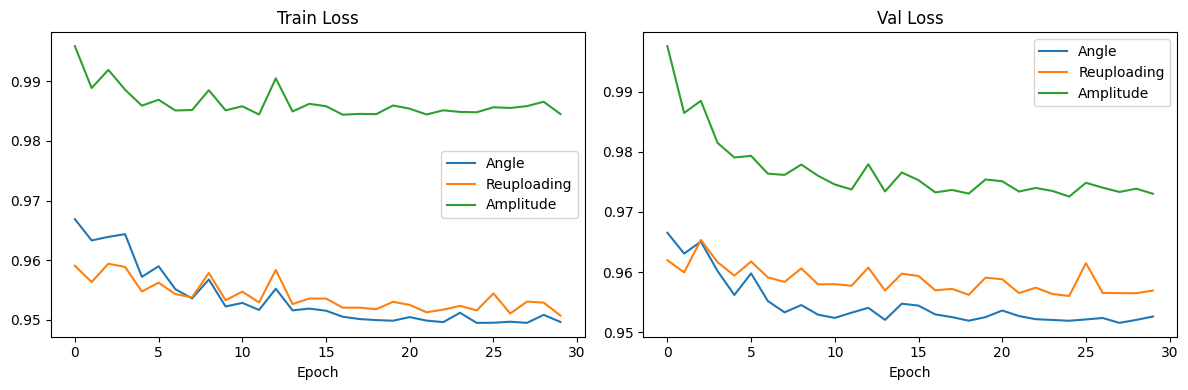

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, res in [('Angle', res_angle), ('Reuploading', res_reupload), ('Amplitude', res_amplitude)]:
    axes[0].plot(res['train_losses'], label=name)
    axes[1].plot(res['val_losses'], label=name)

axes[0].set_title('Train Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].set_title('Val Loss');   axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/03_encoding_comparison.png', dpi=150)
plt.show()

## Observations

*(Fill in after running)*

- Which encoding achieves the best AUC?
- Does data reuploading improve expressibility as expected?
- How does amplitude encoding compare given the qubit overhead?